In [2]:
import polars as pl
import numpy as np
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# Temporal analysis of ERC-20 and ERC-721 contracts

## Results for ERC-20 contracts

In [2]:
ft_event_count = pl.read_csv('results/ft/temporal/ft_category_count.csv', try_parse_dates=True)
ft_event_count

block_id,layer-2,content,defi,storage,other,blockchain,gaming,multimedia,mining,timestamp
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,datetime[μs]
2607941,1,0,0,0,0,0,0,0,0,2016-11-11 15:43:21
2607958,1,0,0,0,0,0,0,0,0,2016-11-11 15:46:36
2607959,1,0,0,0,0,0,0,0,0,2016-11-11 15:46:57
2607960,2,0,0,0,0,0,0,0,0,2016-11-11 15:47:04
2607992,1,0,0,0,0,0,0,0,0,2016-11-11 15:52:41
…,…,…,…,…,…,…,…,…,…,…
14999995,0,0,46,0,1,0,0,0,0,2022-06-21 02:27:32
14999996,1,1,46,0,1,1,1,0,0,2022-06-21 02:27:35
14999997,0,0,57,1,1,2,0,0,0,2022-06-21 02:27:51


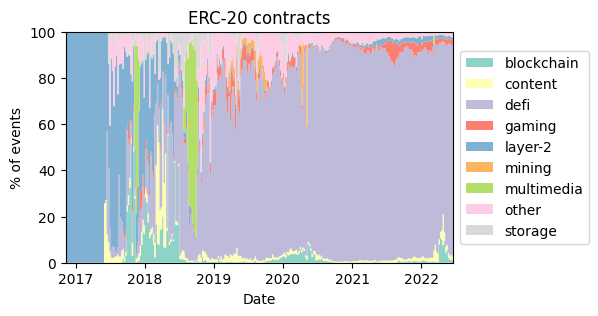

In [ ]:
FT_CATEGORIES = ['blockchain','content','defi','gaming','layer-2','mining','multimedia','other','storage']
ft_event_count_grouped = (
    ft_event_count.with_columns(total=pl.sum_horizontal(FT_CATEGORIES))
    .group_by_dynamic("timestamp", every="1w")
    .agg(pl.col("blockchain").sum(),
         pl.col("content").sum(),
         pl.col("defi").sum(),
         pl.col("gaming").sum(),
         pl.col("layer-2").sum(),
         pl.col("mining").sum(),
         pl.col("multimedia").sum(),
         pl.col("other").sum(),
         pl.col("storage").sum(),
         pl.col("total").sum())
)
for category in FT_CATEGORIES:
    ft_event_count_grouped = ft_event_count_grouped.with_columns((pl.col(category)*100/pl.col("total")).alias(f"{category}_perc"))

#x = event_count_ext[event_count_ext['sum'] > 0]
#dates = x.timestamp.astype(dtype='datetime64[s]')

fig = plt.figure(figsize=(5, 3))
ax1 = fig.add_subplot()
ax1.set_title('ERC-20 contracts')
ax1.set_xlabel('Date')
ax1.set_ylabel('% of events')
ax1.stackplot(ft_event_count_grouped['timestamp'], 
              ft_event_count_grouped['blockchain_perc'], 
              ft_event_count_grouped['content_perc'], 
              ft_event_count_grouped['defi_perc'], 
              ft_event_count_grouped['gaming_perc'], 
              ft_event_count_grouped['layer-2_perc'], 
              ft_event_count_grouped['mining_perc'],
              ft_event_count_grouped['multimedia_perc'],
              ft_event_count_grouped['other_perc'],
              ft_event_count_grouped['storage_perc'],
             colors=['#8dd3c7','#ffffb3','#bebada','#fb8072','#80b1d3','#fdb462','#b3de69','#fccde5','#d9d9d9'],
             labels=['blockchain','content','defi','gaming','layer-2','mining','multimedia','other','storage'], 
             step='post')
ax1.margins(0,0)
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
#ax1.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
plt.savefig("figures/ft_events_category.pdf", format='pdf', bbox_inches='tight')
plt.show()

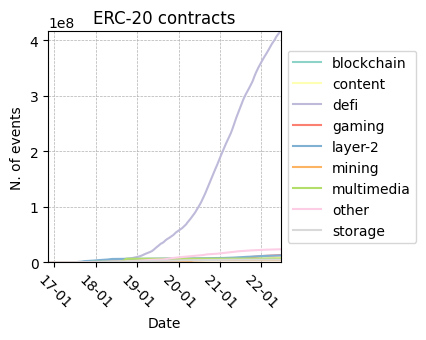

In [6]:
colors=['#8dd3c7','#ffffb3','#bebada','#fb8072','#80b1d3','#fdb462','#b3de69','#fccde5','#d9d9d9']
labels=['blockchain','content','defi','gaming','layer-2','mining','multimedia','other','storage']

fig = plt.figure(figsize=(3, 3))
ax1 = fig.add_subplot()
ax1.set_title('ERC-20 contracts')
ax1.set_xlabel('Date')
ax1.set_ylabel('N. of events')
for i in range(0, len(labels)):
    ax1.plot(ft_event_count_grouped['timestamp'], np.cumsum(ft_event_count_grouped[labels[i]]), color=colors[i], label=labels[i])
ax1.margins(0,0)
ax1.grid(which='major', linestyle='--', linewidth=0.5)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
ax1.tick_params(axis='x', labelrotation=-45)
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.savefig("figures/ft_events_category_cumulative_1.pdf", format='pdf', bbox_inches='tight')
plt.show()

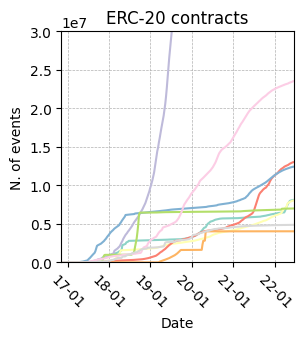

In [8]:
colors=['#8dd3c7','#ffffb3','#bebada','#fb8072','#80b1d3','#fdb462','#b3de69','#fccde5','#d9d9d9']
labels=['blockchain','content','defi','gaming','layer-2','mining','multimedia','other','storage']

fig = plt.figure(figsize=(3, 3))
ax1 = fig.add_subplot()
ax1.set_title('ERC-20 contracts')
ax1.set_xlabel('Date')
ax1.set_ylabel('N. of events')
for i in range(0, len(labels)):
    ax1.plot(ft_event_count_grouped['timestamp'], np.cumsum(ft_event_count_grouped[labels[i]]), color=colors[i], label=labels[i])
ax1.margins(0,0)
ax1.grid(which='major', linestyle='--', linewidth=0.5)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
ax1.tick_params(axis='x', labelrotation=-45)
#ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax1.set_ylim(0, (0.3*1e8))

plt.savefig("figures/ft_events_category_cumulative_2.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [3]:
ft_contract_count = pl.read_csv('results/ft/temporal/ft_contract_count.csv', try_parse_dates=True)
ft_contract_count

block_id,1215,2556,2715,2874,2887,2875,3258,3296,3486,4761,5462,5899,6158,6207,6423,6879,7195,9596,10188,11826,12071,13532,13567,13653,14528,17104,20227,26342,27691,34067,37663,37955,39199,42312,44715,45132,…,113404,115763,117850,124968,124573,126243,126709,127260,133873,140752,141851,147433,151252,151771,151770,153781,158543,164002,166501,122425,168878,170356,175035,181609,182673,191878,229078,232189,248702,258765,259768,272942,295916,336741,346977,360126,timestamp
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,datetime[μs]
2607941,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2016-11-11 15:43:21
2607958,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2016-11-11 15:46:36
2607959,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2016-11-11 15:46:57
2607960,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2016-11-11 15:47:04
2607992,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2016-11-11 15:52:41
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
14999995,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,26,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,2022-06-21 02:27:32
14999996,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,16,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,2,0,0,2,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,2022-06-21 02:27:35
14999997,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,21,13,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,4,0,0,0,0,0,0,0,0,1,0,0,1,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2022-06-21 02:27:51


In [40]:
columns = [c for c in ft_contract_count.drop("block_id", "timestamp").columns]
grouped = ft_contract_count.group_by_dynamic("timestamp", every="1w").agg([pl.col(c).sum() for c in columns])
top1s = []
top2s = []
top3s = []
remaining = []
total = []
for row in grouped[columns].iter_rows():
    values = list(row)
    s = sum(values)
    t1, t2, t3 = sorted(values, reverse=True)[:3]
    r = s - (t1 + t2 + t3)
    top1s.append(t1)
    top2s.append(t2)
    top3s.append(t3)
    remaining.append(r)
    total.append(s)
res = (
    pl.DataFrame({'timestamp':grouped['timestamp'], 'top1':top1s, 'top2':top2s, 'top3':top3s, 'remaining':remaining, 'total':total})
    .with_columns(
        top1_perc=pl.col("top1")*100/pl.col("total"),
        top2_perc=pl.col("top2")*100/pl.col("total"),
        top3_perc=pl.col("top3")*100/pl.col("total"),
        remaining_perc=pl.col("remaining")*100/pl.col("total")
    )
)
res

timestamp,top1,top2,top3,remaining,total,top1_perc,top2_perc,top3_perc,remaining_perc
datetime[μs],i64,i64,i64,i64,i64,f64,f64,f64,f64
2016-11-07 00:00:00,425,0,0,0,425,100.0,0.0,0.0,0.0
2016-11-14 00:00:00,1088,0,0,0,1088,100.0,0.0,0.0,0.0
2016-11-21 00:00:00,607,0,0,0,607,100.0,0.0,0.0,0.0
2016-11-28 00:00:00,338,0,0,0,338,100.0,0.0,0.0,0.0
2016-12-05 00:00:00,247,0,0,0,247,100.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…
2022-05-23 00:00:00,686800,538363,417911,559455,2202529,31.182336,24.442947,18.974143,25.400574
2022-05-30 00:00:00,552341,474441,374714,418565,1820061,30.347389,26.067313,20.587991,22.997306
2022-06-06 00:00:00,614919,510704,416603,480176,2022402,30.405379,25.252348,20.599416,23.742856


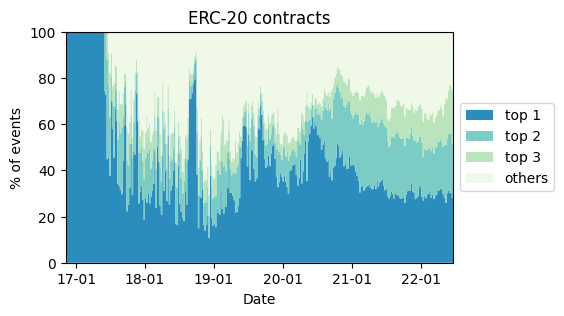

In [41]:
fig = plt.figure(figsize=(5, 3))
ax1 = fig.add_subplot()
ax1.set_title('ERC-20 contracts')
ax1.set_xlabel('Date')
ax1.set_ylabel('% of events')
ax1.stackplot(res['timestamp'], res['top1_perc'], res['top2_perc'], res['top3_perc'], res['remaining_perc'],
            colors=['#2b8cbe', '#7bccc4', '#bae4bc', '#f0f9e8'],
            labels=['top 1', 'top 2', 'top 3', 'others'], 
            step='post')
ax1.margins(0,0)
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))

plt.savefig("figures/ft_events_top.pdf", format='pdf', bbox_inches='tight')
plt.show()

## Results for ERC-721 contracts

In [52]:
nft_event_count = pl.read_csv('results/nft/temporal/nft_category_count.csv', try_parse_dates=True)
nft_event_count = nft_event_count.rename({'None':'other'})
nft_event_count

block_id,gaming,virtual-worlds,art,other,domain-names,pfps,timestamp
i64,i64,i64,i64,i64,i64,i64,datetime[μs]
6142996,9,0,0,0,0,0,2018-08-14 00:44:00
6143381,1,0,0,0,0,0,2018-08-14 02:20:31
6143402,1,0,0,0,0,0,2018-08-14 02:26:13
6143713,1,0,0,0,0,0,2018-08-14 03:37:21
6143715,1,0,0,0,0,0,2018-08-14 03:37:53
…,…,…,…,…,…,…,…
14999993,0,0,0,0,1,0,2022-06-21 02:26:35
14999994,0,0,0,0,3,2,2022-06-21 02:27:15
14999996,0,0,0,0,3,1,2022-06-21 02:27:35


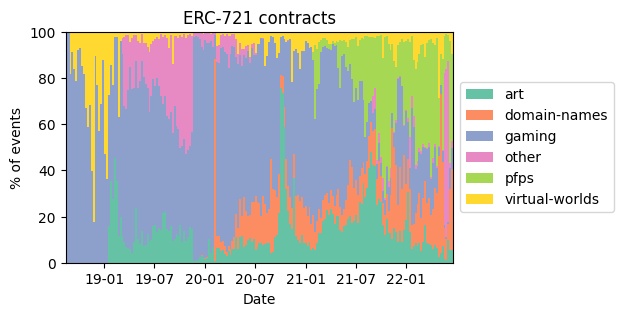

In [53]:
NFT_CATEGORIES = ['art', 'domain-names', 'gaming', 'other', 'pfps', 'virtual-worlds']
nft_event_count_grouped = (
    nft_event_count.group_by_dynamic("timestamp", every="1w")
    .agg([pl.col(c).sum() for c in NFT_CATEGORIES])
    .with_columns(total=pl.sum_horizontal(NFT_CATEGORIES))
)
for category in NFT_CATEGORIES:
    nft_event_count_grouped = nft_event_count_grouped.with_columns((pl.col(category)*100/pl.col("total")).alias(f"{category}_perc"))

fig = plt.figure(figsize=(5, 3))
ax1 = fig.add_subplot()
ax1.set_title('ERC-721 contracts')
ax1.set_xlabel('Date')
ax1.set_ylabel('% of events')
ax1.stackplot(
    nft_event_count_grouped['timestamp'], 
    nft_event_count_grouped['art_perc'], 
    nft_event_count_grouped['domain-names_perc'], 
    nft_event_count_grouped['gaming_perc'], 
    nft_event_count_grouped['other_perc'], 
    nft_event_count_grouped['pfps_perc'], 
    nft_event_count_grouped['virtual-worlds_perc'],
    colors=['#66c2a5','#fc8d62','#8da0cb','#e78ac3','#a6d854','#ffd92f'],
    labels=['art', 'domain-names', 'gaming', 'other', 'pfps', 'virtual-worlds'], 
    step='post')
ax1.margins(0,0)
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
plt.savefig("figures/nft_events_category.pdf", format='pdf', bbox_inches='tight')
plt.show()

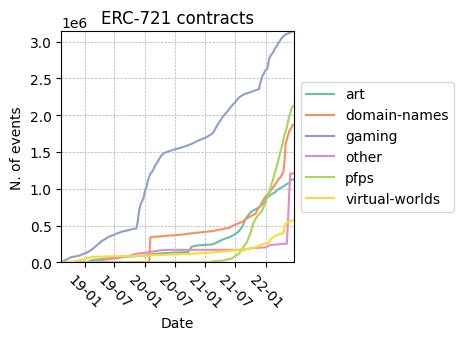

In [55]:
colors=['#66c2a5','#fc8d62','#8da0cb','#e78ac3','#a6d854','#ffd92f']
labels=['art', 'domain-names', 'gaming', 'other', 'pfps', 'virtual-worlds']
fig = plt.figure(figsize=(3, 3))
ax1 = fig.add_subplot()
ax1.set_title('ERC-721 contracts')
ax1.set_xlabel('Date')
ax1.set_ylabel('N. of events')
for i in range(0, len(labels)):
    ax1.plot(nft_event_count_grouped['timestamp'], np.cumsum(nft_event_count_grouped[labels[i]]), color=colors[i], label=labels[i])
ax1.margins(0,0)
ax1.grid(which='major', linestyle='--', linewidth=0.5)
#ax1.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
ax1.tick_params(axis='x', labelrotation=-45)
plt.savefig("figures/nft_events_category_cumulative.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [56]:
nft_contract_count = pl.read_csv('results/nft/temporal/nft_contract_count.csv', try_parse_dates=True)
nft_contract_count

block_id,225,245,247,316,501,535,651,784,1699,2147,2265,2316,2846,4368,4512,5485,6668,7003,7058,8611,8895,9817,9962,10178,10976,11222,11558,11858,11948,11966,12510,12611,12622,12803,13065,13665,…,26876,27226,27630,28775,29849,29809,30134,33964,37665,37977,38790,45275,47203,47620,51735,53545,54275,59214,61566,64501,69158,70918,70557,71435,71622,71787,72037,72038,69298,74179,74299,74566,75125,75633,75878,78048,timestamp
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,datetime[μs]
6142996,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2018-08-14 00:44:00
6143381,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2018-08-14 02:20:31
6143402,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2018-08-14 02:26:13
6143713,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2018-08-14 03:37:21
6143715,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2018-08-14 03:37:53
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
14999993,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2022-06-21 02:26:35
14999994,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2022-06-21 02:27:15
14999996,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2022-06-21 02:27:35


In [57]:
columns = [c for c in nft_contract_count.drop("block_id", "timestamp").columns]
grouped = nft_contract_count.group_by_dynamic("timestamp", every="1w").agg([pl.col(c).sum() for c in columns])
top1s = []
top2s = []
top3s = []
remaining = []
total = []
for row in grouped[columns].iter_rows():
    values = list(row)
    s = sum(values)
    t1, t2, t3 = sorted(values, reverse=True)[:3]
    r = s - (t1 + t2 + t3)
    top1s.append(t1)
    top2s.append(t2)
    top3s.append(t3)
    remaining.append(r)
    total.append(s)
res = (
    pl.DataFrame({'timestamp':grouped['timestamp'], 'top1':top1s, 'top2':top2s, 'top3':top3s, 'remaining':remaining, 'total':total})
    .with_columns(
        top1_perc=pl.col("top1")*100/pl.col("total"),
        top2_perc=pl.col("top2")*100/pl.col("total"),
        top3_perc=pl.col("top3")*100/pl.col("total"),
        remaining_perc=pl.col("remaining")*100/pl.col("total")
    )
)
res

timestamp,top1,top2,top3,remaining,total,top1_perc,top2_perc,top3_perc,remaining_perc
datetime[μs],i64,i64,i64,i64,i64,f64,f64,f64,f64
2018-08-13 00:00:00,4803,0,0,0,4803,100.0,0.0,0.0,0.0
2018-08-20 00:00:00,5591,0,0,0,5591,100.0,0.0,0.0,0.0
2018-08-27 00:00:00,6972,1639,416,0,9027,77.234962,18.156641,4.608397,0.0
2018-09-03 00:00:00,8016,1377,903,0,10296,77.855478,13.374126,8.770396,0.0
2018-09-10 00:00:00,7314,1591,910,0,9815,74.518594,16.209883,9.271523,0.0
…,…,…,…,…,…,…,…,…,…
2022-05-23 00:00:00,201540,68982,56471,194708,521701,38.631323,13.222516,10.824399,37.321761
2022-05-30 00:00:00,147451,121812,34815,90380,394458,37.380659,30.880854,8.826035,22.912452
2022-06-06 00:00:00,30672,27339,5999,51291,115301,26.601677,23.710983,5.202904,44.484436


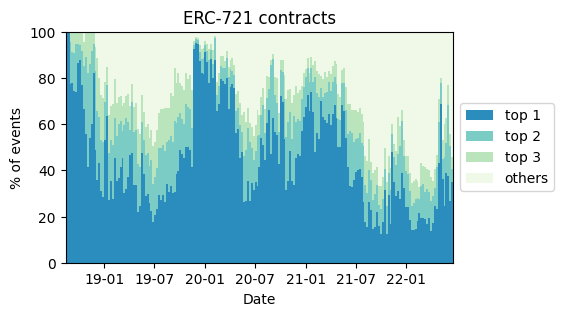

In [58]:
fig = plt.figure(figsize=(5, 3))
ax1 = fig.add_subplot()
ax1.set_title('ERC-721 contracts')
ax1.set_xlabel('Date')
ax1.set_ylabel('% of events')
ax1.stackplot(res['timestamp'], res['top1_perc'], res['top2_perc'], res['top3_perc'], res['remaining_perc'],
            colors=['#2b8cbe', '#7bccc4', '#bae4bc', '#f0f9e8'],
            labels=['top 1', 'top 2', 'top 3', 'others'], 
            step='post')
ax1.margins(0,0)
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
plt.savefig("figures/nft_events_top.pdf", format='pdf', bbox_inches='tight')
plt.show()